<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/Heterogeneoous_Quantum_System_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

Subsystem Reference Data:


,name,role,native_strength,key_risk,evidence
0,Neutral atom Rydberg QPU,Main programmable entangling fabric,"Parallel CZ layers, long coherence, reconfigur...","Rydberg crosstalk, atom loss, optical alignmen...",Evered 2023; Manetsch 2025; Bluvstein 2024
1,Quantum photonic IC,Fusion and interconnect processor,"Time bin resources, PNR detection, fiber netwo...","Loss, phase drift, detector efficiency, multip...",Bartolucci 2023; Arrazola 2021; Aghaee Rad 2025
2,Microwave optical translators,Bridge between optical and superconducting dom...,"LiNbO3 EO paths, optomechanics, Rydberg ensembles","Added noise, low overall efficiency, pump leakage",Holzgrafe 2020; Sahu 2022; Borowka 2024
3,Superconducting cat memory,Noise biased logical storage and refresh opera...,Passive bit flip suppression and repetition ca...,Bias degradation during gates and parity checks,Lescanne 2020; Guillaud 2019; Puri 2020
4,Transmon ancilla layer,"Parity checks, SNAP orchestration, and system ...",Microwave nonlinear control and circuit QED in...,"Leakage, spectral crowding, ancilla induced de...",Rigetti 2010; Chow 2013; Larsen 2015
5,Cryogenic control and RAM,"Local microcode, waveform cache, timing, and a...",Cryo CMOS memory with SFQ timing primitives,"Thermal load, quasiparticles, electromagnetic ...",Underwood 2024; Mukhanov 2011; Herr 2011



Interface Reference Data:


,interface,efficiency,added_noise_photons,latency_us,risk_score
0,Atom to atom Rydberg gate,0.995,0.00,0.50,2
1,Atom to photonic chip link,0.700,0.05,5.00,3
2,Photonic fusion fabric,0.750,0.05,1.00,3
3,Microwave to optical translator,0.100,0.80,10.00,4
4,Cat memory to transmon parity,0.980,0.02,2.00,3
5,Cryogenic control to qubit plane,0.990,0.00,0.05,3



Compliance Evaluation Data:


,interface,efficiency_ok,noise_ok,risk_ok,stage_gate_pass
0,Atom to atom Rydberg gate,True,True,True,True
1,Atom to photonic chip link,True,True,True,True
2,Photonic fusion fabric,True,True,True,True
3,Microwave to optical translator,True,True,False,False
4,Cat memory to transmon parity,True,True,True,True
5,Cryogenic control to qubit plane,True,True,True,True



Interfaces requiring focused mitigation:
* Microwave to optical translator


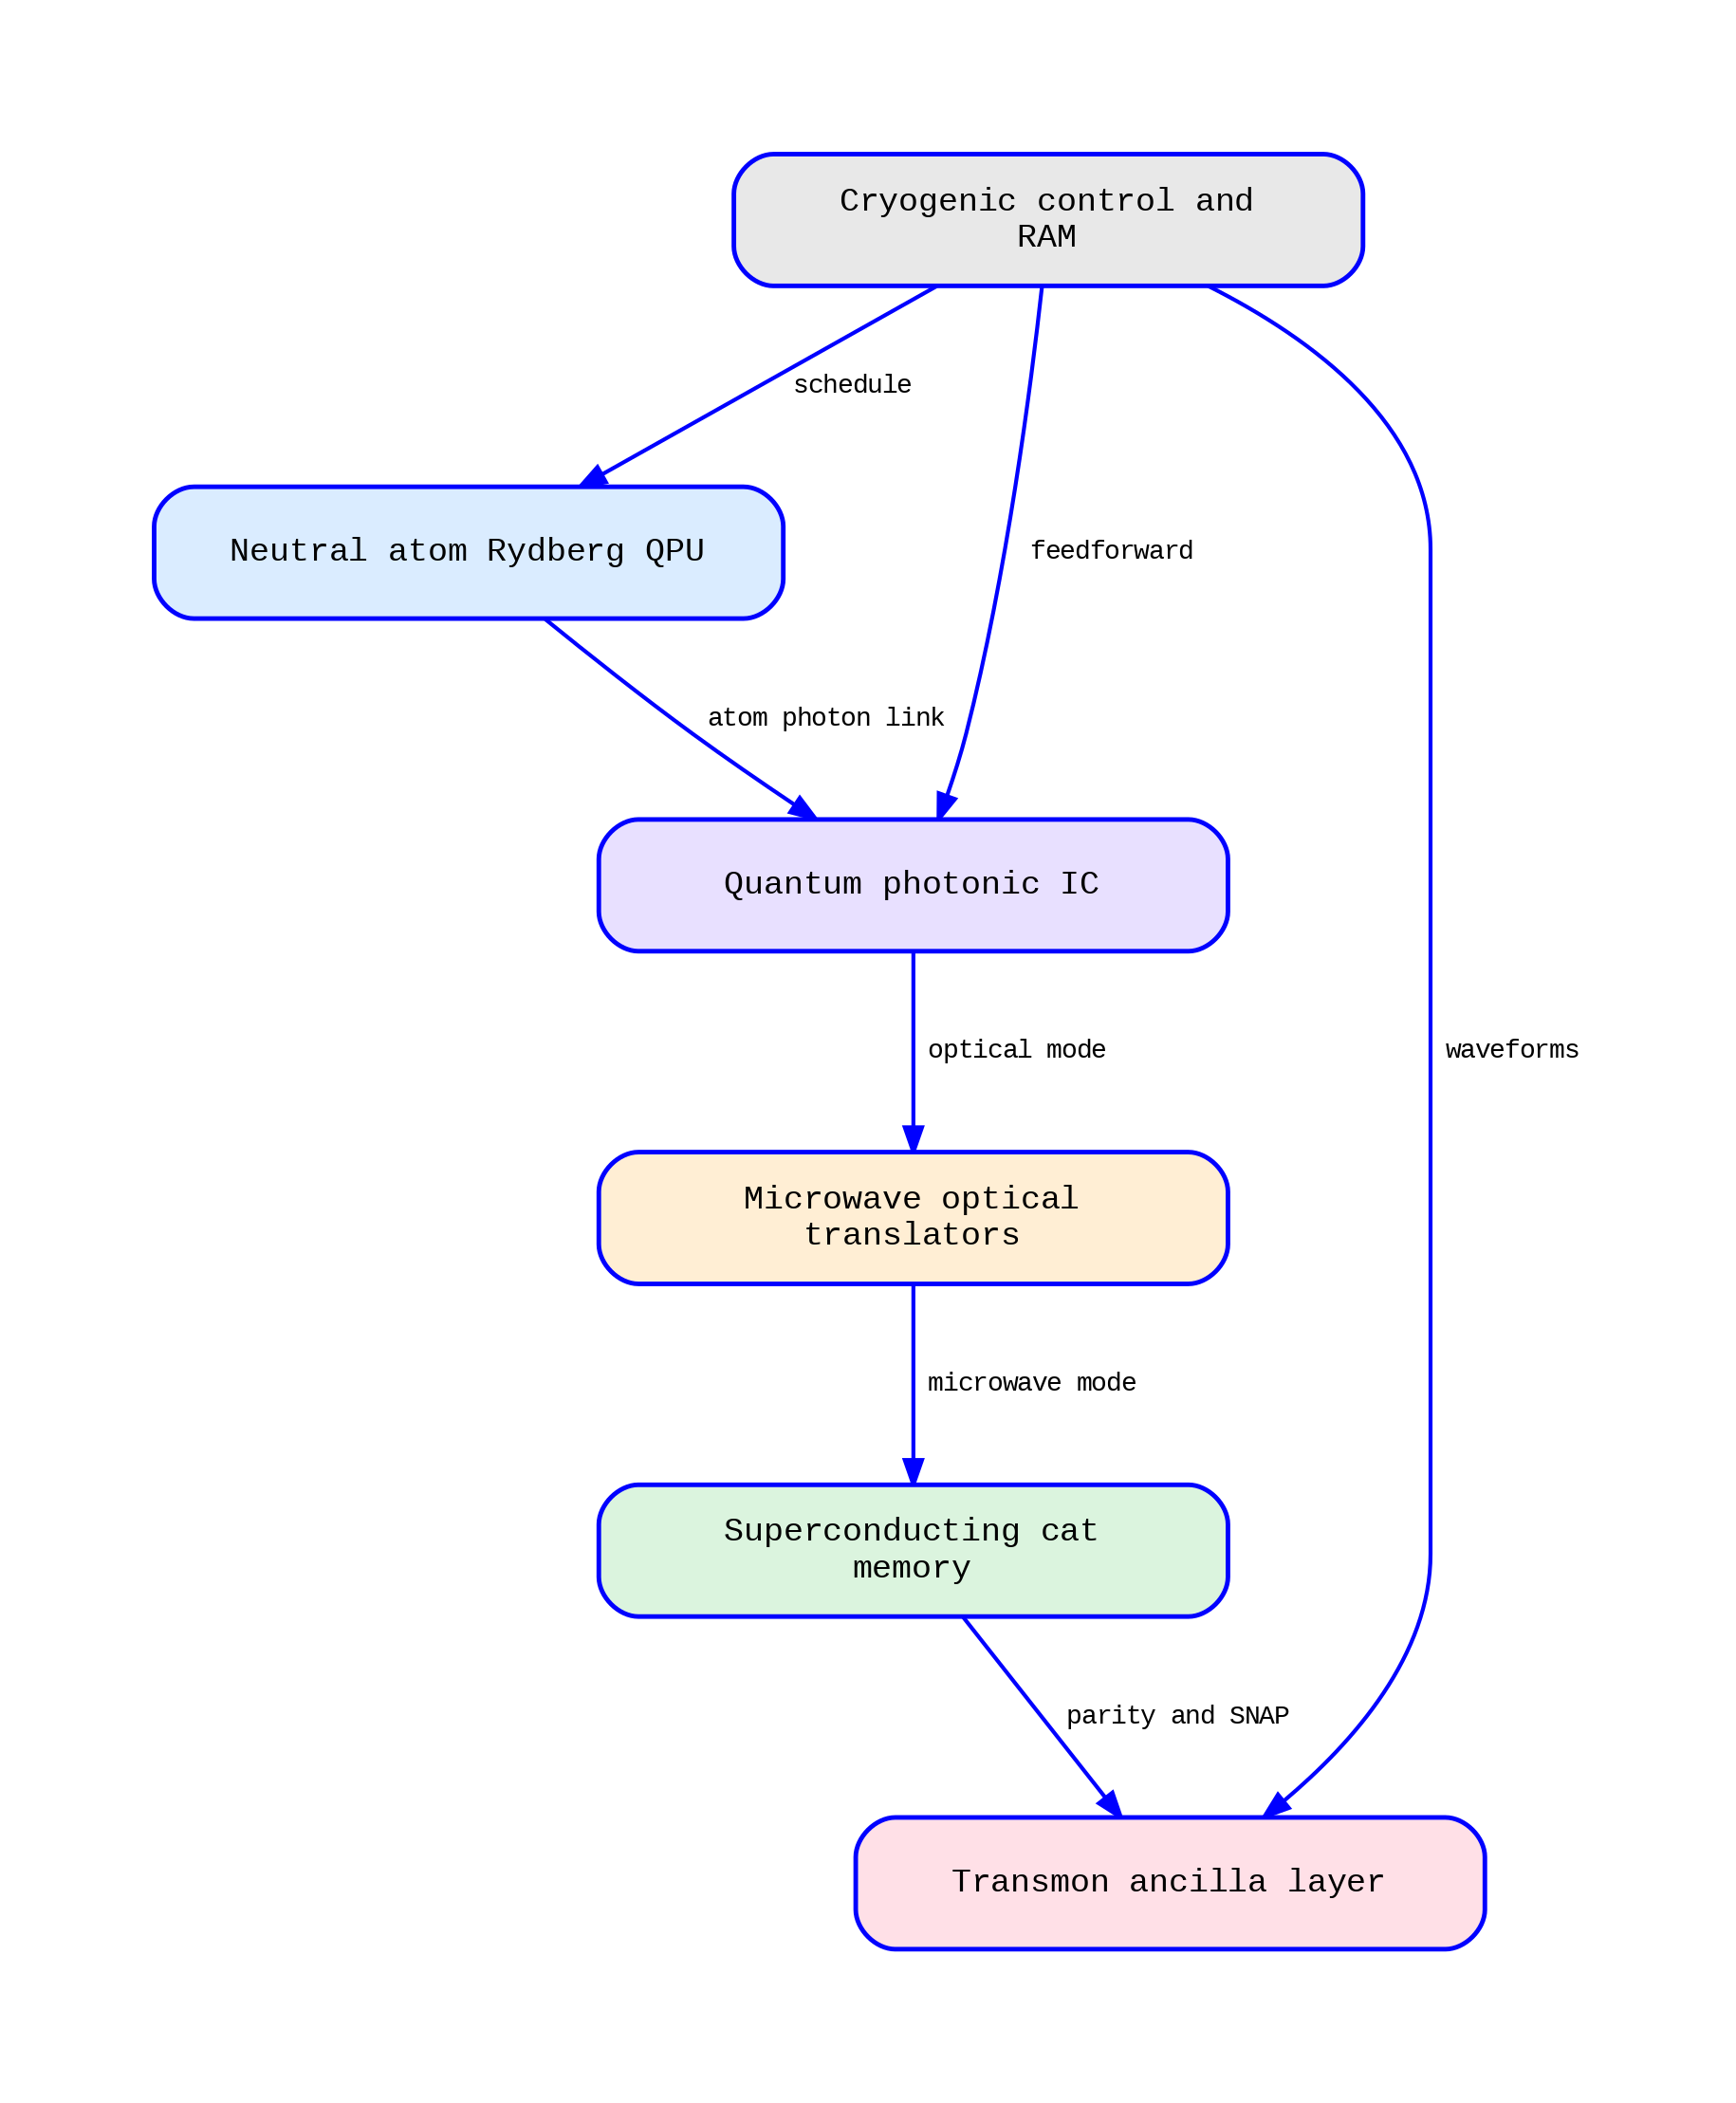


Rendered Graphviz PNG: heterogeneous_architecture_graph.png


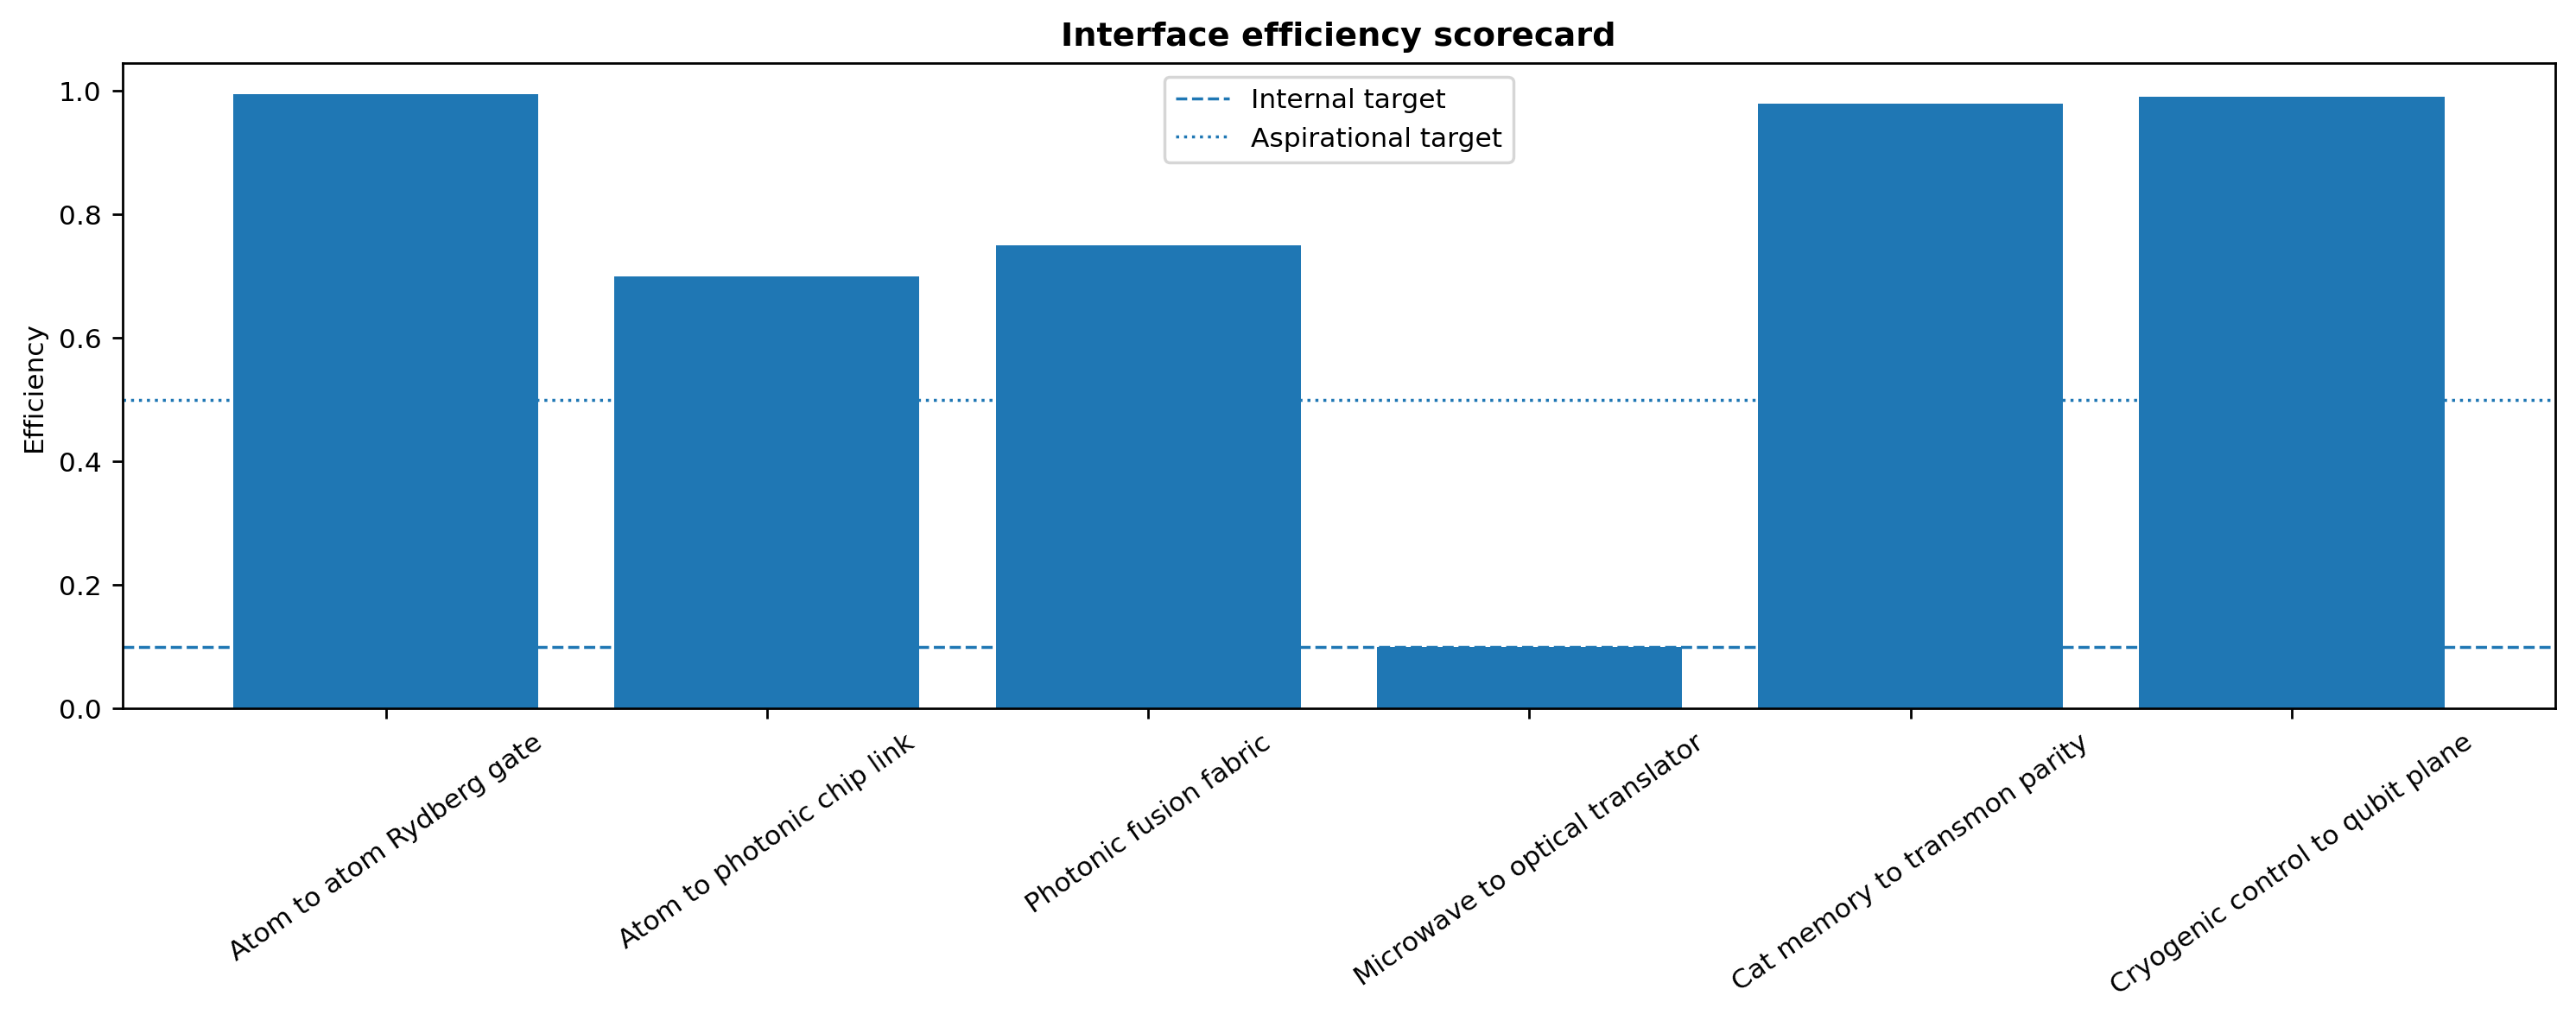

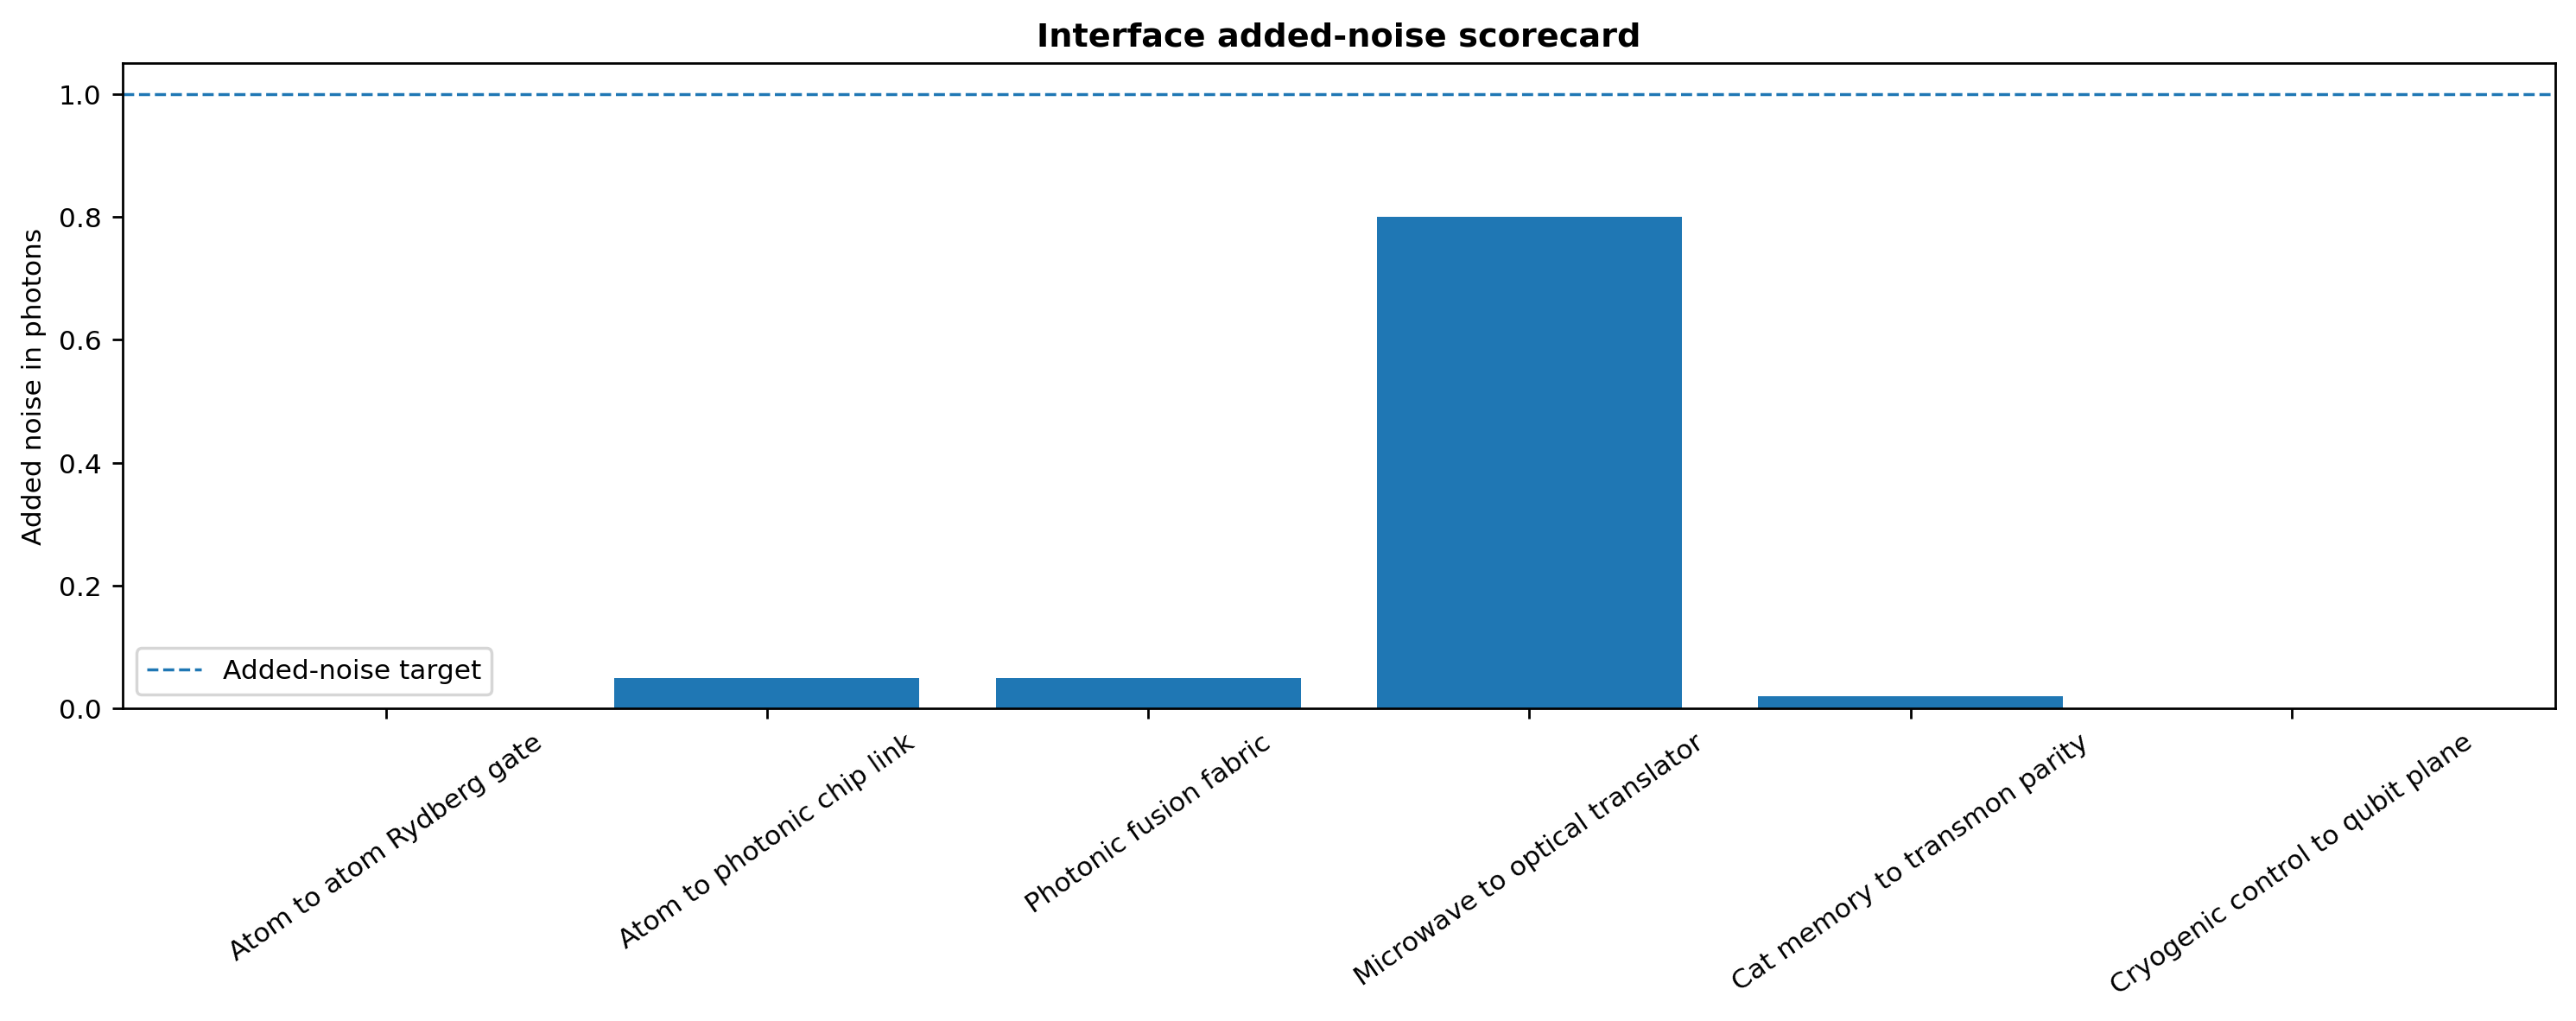

In [ ]:
"""Analyze and visualize a heterogeneous quantum architecture.
"""

from dataclasses import asdict, dataclass
from pathlib import Path
from textwrap import wrap
from typing import Iterable

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

try:
    from google.colab import files

    IN_COLAB = True
except ImportError:
    IN_COLAB = False


# =============================================================================
# CONTROL KNOBS
# =============================================================================

ARCHITECT_NAME = "Onri Jay Benally"
RANDOM_SEED = 7

FIGURE_WIDTH_IN = 12.0
FIGURE_HEIGHT_IN = 4.8
MPL_DPI = 250

INTERNAL_EFFICIENCY_TARGET = 0.10
ASPIRATIONAL_EFFICIENCY_TARGET = 0.50
ADDED_NOISE_TARGET_PHOTONS = 1.0
MAX_ALLOWED_STAGE_RISK = 3

DOWNLOAD_GRAPH_PNG = False
DOWNLOAD_PLOT_PNGS = False

GRAPH_OUTPUT_STEM = "heterogeneous_architecture_graph"
GRAPH_OUTPUT_FORMAT = "png"
GRAPH_DPI = 250
GRAPH_PREVIEW_WIDTH_PX = 1200

GRAPH_RANK_DIRECTION = "TB"
GRAPH_PAD_IN = 0.45
GRAPH_MARGIN_IN = 0.20
GRAPH_NODE_SEPARATION_IN = 0.55
GRAPH_RANK_SEPARATION_IN = 0.72

GRAPH_NODE_WIDTH_IN = 2.65
GRAPH_NODE_HEIGHT_IN = 0.55
GRAPH_NODE_MARGIN = "0.16,0.10"
GRAPH_NODE_FONT_SIZE = 10
GRAPH_EDGE_FONT_SIZE = 8

GRAPH_NODE_WRAP_WIDTH = 24
GRAPH_EDGE_WRAP_WIDTH = 18

# Plain-text label shift. This avoids fragile HTML-like Graphviz labels.
EDGE_LABEL_SHIFT_SPACES = 1


# =============================================================================
# MATPLOTLIB STYLE
# =============================================================================

plt.rcParams["figure.dpi"] = MPL_DPI
plt.rcParams["font.size"] = 9
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 9
plt.rcParams["font.sans-serif"] = [
    "IBM Plex Sans",
    "DejaVu Sans",
    "Arial",
    "sans-serif",
]
plt.rcParams["font.weight"] = "normal"
plt.rcParams["axes.titleweight"] = "semibold"

np.random.seed(RANDOM_SEED)


# =============================================================================
# DATA MODELS
# =============================================================================

@dataclass(frozen=True)
class Subsystem:
    """Describe a subsystem in the heterogeneous quantum architecture."""

    name: str
    role: str
    native_strength: str
    key_risk: str
    evidence: str


@dataclass(frozen=True)
class InterfaceMetric:
    """Store measurable interface targets for domain transitions."""

    interface: str
    efficiency: float
    added_noise_photons: float
    latency_us: float
    risk_score: int


# =============================================================================
# SYSTEM DEFINITIONS
# =============================================================================

SUBSYSTEMS: list[Subsystem] = [
    Subsystem(
        name="Neutral atom Rydberg QPU",
        role="Main programmable entangling fabric",
        native_strength=(
            "Parallel CZ layers, long coherence, reconfigurable layouts"
        ),
        key_risk="Rydberg crosstalk, atom loss, optical alignment drift",
        evidence="Evered 2023; Manetsch 2025; Bluvstein 2024",
    ),
    Subsystem(
        name="Quantum photonic IC",
        role="Fusion and interconnect processor",
        native_strength="Time bin resources, PNR detection, fiber networking",
        key_risk=(
            "Loss, phase drift, detector efficiency, multiplexing overhead"
        ),
        evidence="Bartolucci 2023; Arrazola 2021; Aghaee Rad 2025",
    ),
    Subsystem(
        name="Microwave optical translators",
        role="Bridge between optical and superconducting domains",
        native_strength="LiNbO3 EO paths, optomechanics, Rydberg ensembles",
        key_risk="Added noise, low overall efficiency, pump leakage",
        evidence="Holzgrafe 2020; Sahu 2022; Borowka 2024",
    ),
    Subsystem(
        name="Superconducting cat memory",
        role="Noise biased logical storage and refresh operations",
        native_strength=(
            "Passive bit flip suppression and repetition cat compatibility"
        ),
        key_risk="Bias degradation during gates and parity checks",
        evidence="Lescanne 2020; Guillaud 2019; Puri 2020",
    ),
    Subsystem(
        name="Transmon ancilla layer",
        role="Parity checks, SNAP orchestration, and system readout",
        native_strength=(
            "Microwave nonlinear control and circuit QED integration"
        ),
        key_risk="Leakage, spectral crowding, ancilla induced dephasing",
        evidence="Rigetti 2010; Chow 2013; Larsen 2015",
    ),
    Subsystem(
        name="Cryogenic control and RAM",
        role="Local microcode, waveform cache, timing, and active feedback",
        native_strength="Cryo CMOS memory with SFQ timing primitives",
        key_risk="Thermal load, quasiparticles, electromagnetic coupling",
        evidence="Underwood 2024; Mukhanov 2011; Herr 2011",
    ),
]

INTERFACES: list[InterfaceMetric] = [
    InterfaceMetric("Atom to atom Rydberg gate", 0.995, 0.00, 0.50, 2),
    InterfaceMetric("Atom to photonic chip link", 0.70, 0.05, 5.00, 3),
    InterfaceMetric("Photonic fusion fabric", 0.75, 0.05, 1.00, 3),
    InterfaceMetric("Microwave to optical translator", 0.10, 0.80, 10.00, 4),
    InterfaceMetric("Cat memory to transmon parity", 0.98, 0.02, 2.00, 3),
    InterfaceMetric("Cryogenic control to qubit plane", 0.99, 0.00, 0.05, 3),
]


# =============================================================================
# ANALYTICAL FUNCTIONS
# =============================================================================

def build_subsystem_frame(subsystems: Iterable[Subsystem]) -> pd.DataFrame:
    """Build a subsystem reference table.

    Args:
        subsystems: Subsystem records for the architecture.

    Returns:
        A pandas DataFrame containing subsystem descriptions.
    """
    return pd.DataFrame([asdict(item) for item in subsystems])


def build_interface_frame(metrics: Iterable[InterfaceMetric]) -> pd.DataFrame:
    """Build an interface metric reference table.

    Args:
        metrics: Interface metric records for the architecture.

    Returns:
        A pandas DataFrame containing interface metrics.
    """
    return pd.DataFrame([asdict(item) for item in metrics])


def evaluate_interfaces(metrics: Iterable[InterfaceMetric]) -> pd.DataFrame:
    """Evaluate target compliance for interface metrics.

    Args:
        metrics: Interface metrics requiring evaluation.

    Returns:
        A pandas DataFrame containing verification flags.
    """
    records = []

    for metric in metrics:
        efficiency_ok = metric.efficiency >= INTERNAL_EFFICIENCY_TARGET
        noise_ok = metric.added_noise_photons <= ADDED_NOISE_TARGET_PHOTONS
        risk_ok = metric.risk_score <= MAX_ALLOWED_STAGE_RISK

        records.append(
            {
                "interface": metric.interface,
                "efficiency_ok": efficiency_ok,
                "noise_ok": noise_ok,
                "risk_ok": risk_ok,
                "stage_gate_pass": efficiency_ok and noise_ok and risk_ok,
            }
        )

    return pd.DataFrame(records)


def wrap_graph_label(text: str, width: int) -> str:
    """Wrap a plain-text label for Graphviz rendering.

    Args:
        text: Label text.
        width: Maximum line width in characters.

    Returns:
        A newline-wrapped label string.
    """
    return "\n".join(
        wrap(
            text,
            width=width,
            break_long_words=False,
            break_on_hyphens=False,
        )
    )


def make_shifted_edge_label(text: str, shift_spaces: int) -> str:
    """Build a plain Graphviz edge label with a small visual right shift.

    Args:
        text: Edge label text.
        shift_spaces: Number of leading spaces applied to each label line.

    Returns:
        A wrapped plain-text edge label.
    """
    prefix = " " * max(0, shift_spaces)
    wrapped_lines = wrap(
        text,
        width=GRAPH_EDGE_WRAP_WIDTH,
        break_long_words=False,
        break_on_hyphens=False,
    )

    return "\n".join(f"{prefix}{line}" for line in wrapped_lines)


def build_architecture_graph() -> graphviz.Digraph:
    """Construct a padded Graphviz architecture graph.

    Returns:
        A Graphviz Digraph defining hardware domains and data-flow edges.
    """
    graph_comment = (
        f"Heterogeneous Quantum Architecture, architect: {ARCHITECT_NAME}"
    )
    dot = graphviz.Digraph(comment=graph_comment, engine="dot")

    dot.attr(
        dpi=str(GRAPH_DPI),
        fontname="IBM Plex Sans",
        rankdir=GRAPH_RANK_DIRECTION,
        pad=str(GRAPH_PAD_IN),
        margin=str(GRAPH_MARGIN_IN),
        nodesep=str(GRAPH_NODE_SEPARATION_IN),
        ranksep=str(GRAPH_RANK_SEPARATION_IN),
        outputorder="edgesfirst",
        splines="spline",
        bgcolor="white",
    )

    dot.attr(
        "node",
        shape="box",
        style="filled,rounded",
        fontname="IBM Plex Sans",
        margin=GRAPH_NODE_MARGIN,
        fontsize=str(GRAPH_NODE_FONT_SIZE),
        color="#0000ff",
        penwidth="1.4",
        width=str(GRAPH_NODE_WIDTH_IN),
        height=str(GRAPH_NODE_HEIGHT_IN),
        fixedsize="false",
    )

    dot.attr(
        "edge",
        fontname="IBM Plex Sans",
        fontsize=str(GRAPH_EDGE_FONT_SIZE),
        color="#0000ff",
        penwidth="1.2",
        arrowsize="0.75",
        labeldistance="1.25",
    )

    nodes_with_colors = {
        "Neutral atom Rydberg QPU": "#daecff",
        "Quantum photonic IC": "#e8e0ff",
        "Microwave optical translators": "#ffeed4",
        "Superconducting cat memory": "#dbf4de",
        "Transmon ancilla layer": "#ffe0e7",
        "Cryogenic control and RAM": "#e8e8e8",
    }

    for name, color in nodes_with_colors.items():
        dot.node(
            name,
            wrap_graph_label(name, GRAPH_NODE_WRAP_WIDTH),
            fillcolor=color,
        )

    edges = [
        ("Neutral atom Rydberg QPU", "Quantum photonic IC", "atom photon link"),
        ("Quantum photonic IC", "Microwave optical translators", "optical mode"),
        (
            "Microwave optical translators",
            "Superconducting cat memory",
            "microwave mode",
        ),
        (
            "Superconducting cat memory",
            "Transmon ancilla layer",
            "parity and SNAP",
        ),
        ("Cryogenic control and RAM", "Transmon ancilla layer", "waveforms"),
        ("Cryogenic control and RAM", "Neutral atom Rydberg QPU", "schedule"),
        ("Cryogenic control and RAM", "Quantum photonic IC", "feedforward"),
    ]

    for source, destination, label in edges:
        dot.edge(
            source,
            destination,
            label=make_shifted_edge_label(
                label,
                EDGE_LABEL_SHIFT_SPACES,
            ),
        )

    return dot


def render_and_display_graph(graph: graphviz.Digraph) -> Path | None:
    """Render a Graphviz graph to PNG and display it in the notebook.

    Args:
        graph: Graphviz graph object.

    Returns:
        Path to the rendered PNG image when rendering succeeds, otherwise None.
    """
    try:
        rendered_path = Path(
            graph.render(
                GRAPH_OUTPUT_STEM,
                format=GRAPH_OUTPUT_FORMAT,
                cleanup=True,
            )
        )
    except graphviz.backend.execute.CalledProcessError as error:
        print("\nGraphviz rendering failed. Matplotlib plots will continue.")
        print(error)
        return None

    display(Image(filename=str(rendered_path), width=GRAPH_PREVIEW_WIDTH_PX))

    if DOWNLOAD_GRAPH_PNG and IN_COLAB:
        files.download(str(rendered_path))

    return rendered_path


def plot_interface_efficiency(frame: pd.DataFrame) -> None:
    """Render a bar chart of interface efficiencies.

    Args:
        frame: DataFrame containing interface and efficiency columns.
    """
    _, axis = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))

    axis.bar(frame["interface"], frame["efficiency"])
    axis.axhline(
        INTERNAL_EFFICIENCY_TARGET,
        linestyle="--",
        linewidth=1.0,
        label="Internal target",
    )
    axis.axhline(
        ASPIRATIONAL_EFFICIENCY_TARGET,
        linestyle=":",
        linewidth=1.0,
        label="Aspirational target",
    )

    axis.set_ylabel("Efficiency")
    axis.set_title("Interface efficiency scorecard")
    axis.tick_params(axis="x", rotation=35)
    axis.legend(loc="best")

    plt.tight_layout()

    if DOWNLOAD_PLOT_PNGS:
        file_name = "interface_efficiency_scorecard.png"
        plt.savefig(file_name, bbox_inches="tight")
        if IN_COLAB:
            files.download(file_name)

    plt.show()


def plot_added_noise(frame: pd.DataFrame) -> None:
    """Render a bar chart of added-noise budgets.

    Args:
        frame: DataFrame containing interface and added-noise columns.
    """
    _, axis = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))

    axis.bar(frame["interface"], frame["added_noise_photons"])
    axis.axhline(
        ADDED_NOISE_TARGET_PHOTONS,
        linestyle="--",
        linewidth=1.0,
        label="Added-noise target",
    )

    axis.set_ylabel("Added noise in photons")
    axis.set_title("Interface added-noise scorecard")
    axis.tick_params(axis="x", rotation=35)
    axis.legend(loc="best")

    plt.tight_layout()

    if DOWNLOAD_PLOT_PNGS:
        file_name = "interface_added_noise_scorecard.png"
        plt.savefig(file_name, bbox_inches="tight")
        if IN_COLAB:
            files.download(file_name)

    plt.show()


# =============================================================================
# EXECUTION
# =============================================================================

subsystem_frame = build_subsystem_frame(SUBSYSTEMS)
interface_frame = build_interface_frame(INTERFACES)
compliance_frame = evaluate_interfaces(INTERFACES)

print("Subsystem Reference Data:")
display(subsystem_frame)

print("\nInterface Reference Data:")
display(interface_frame)

print("\nCompliance Evaluation Data:")
display(compliance_frame)

failing_interfaces = compliance_frame.loc[
    ~compliance_frame["stage_gate_pass"],
    "interface",
]

print("\nInterfaces requiring focused mitigation:")
for interface_name in failing_interfaces:
    print(f"* {interface_name}")

architecture_graph = build_architecture_graph()
rendered_graph_path = render_and_display_graph(architecture_graph)

if rendered_graph_path is not None:
    print(f"\nRendered Graphviz PNG: {rendered_graph_path}")

plot_interface_efficiency(interface_frame)
plot_added_noise(interface_frame)

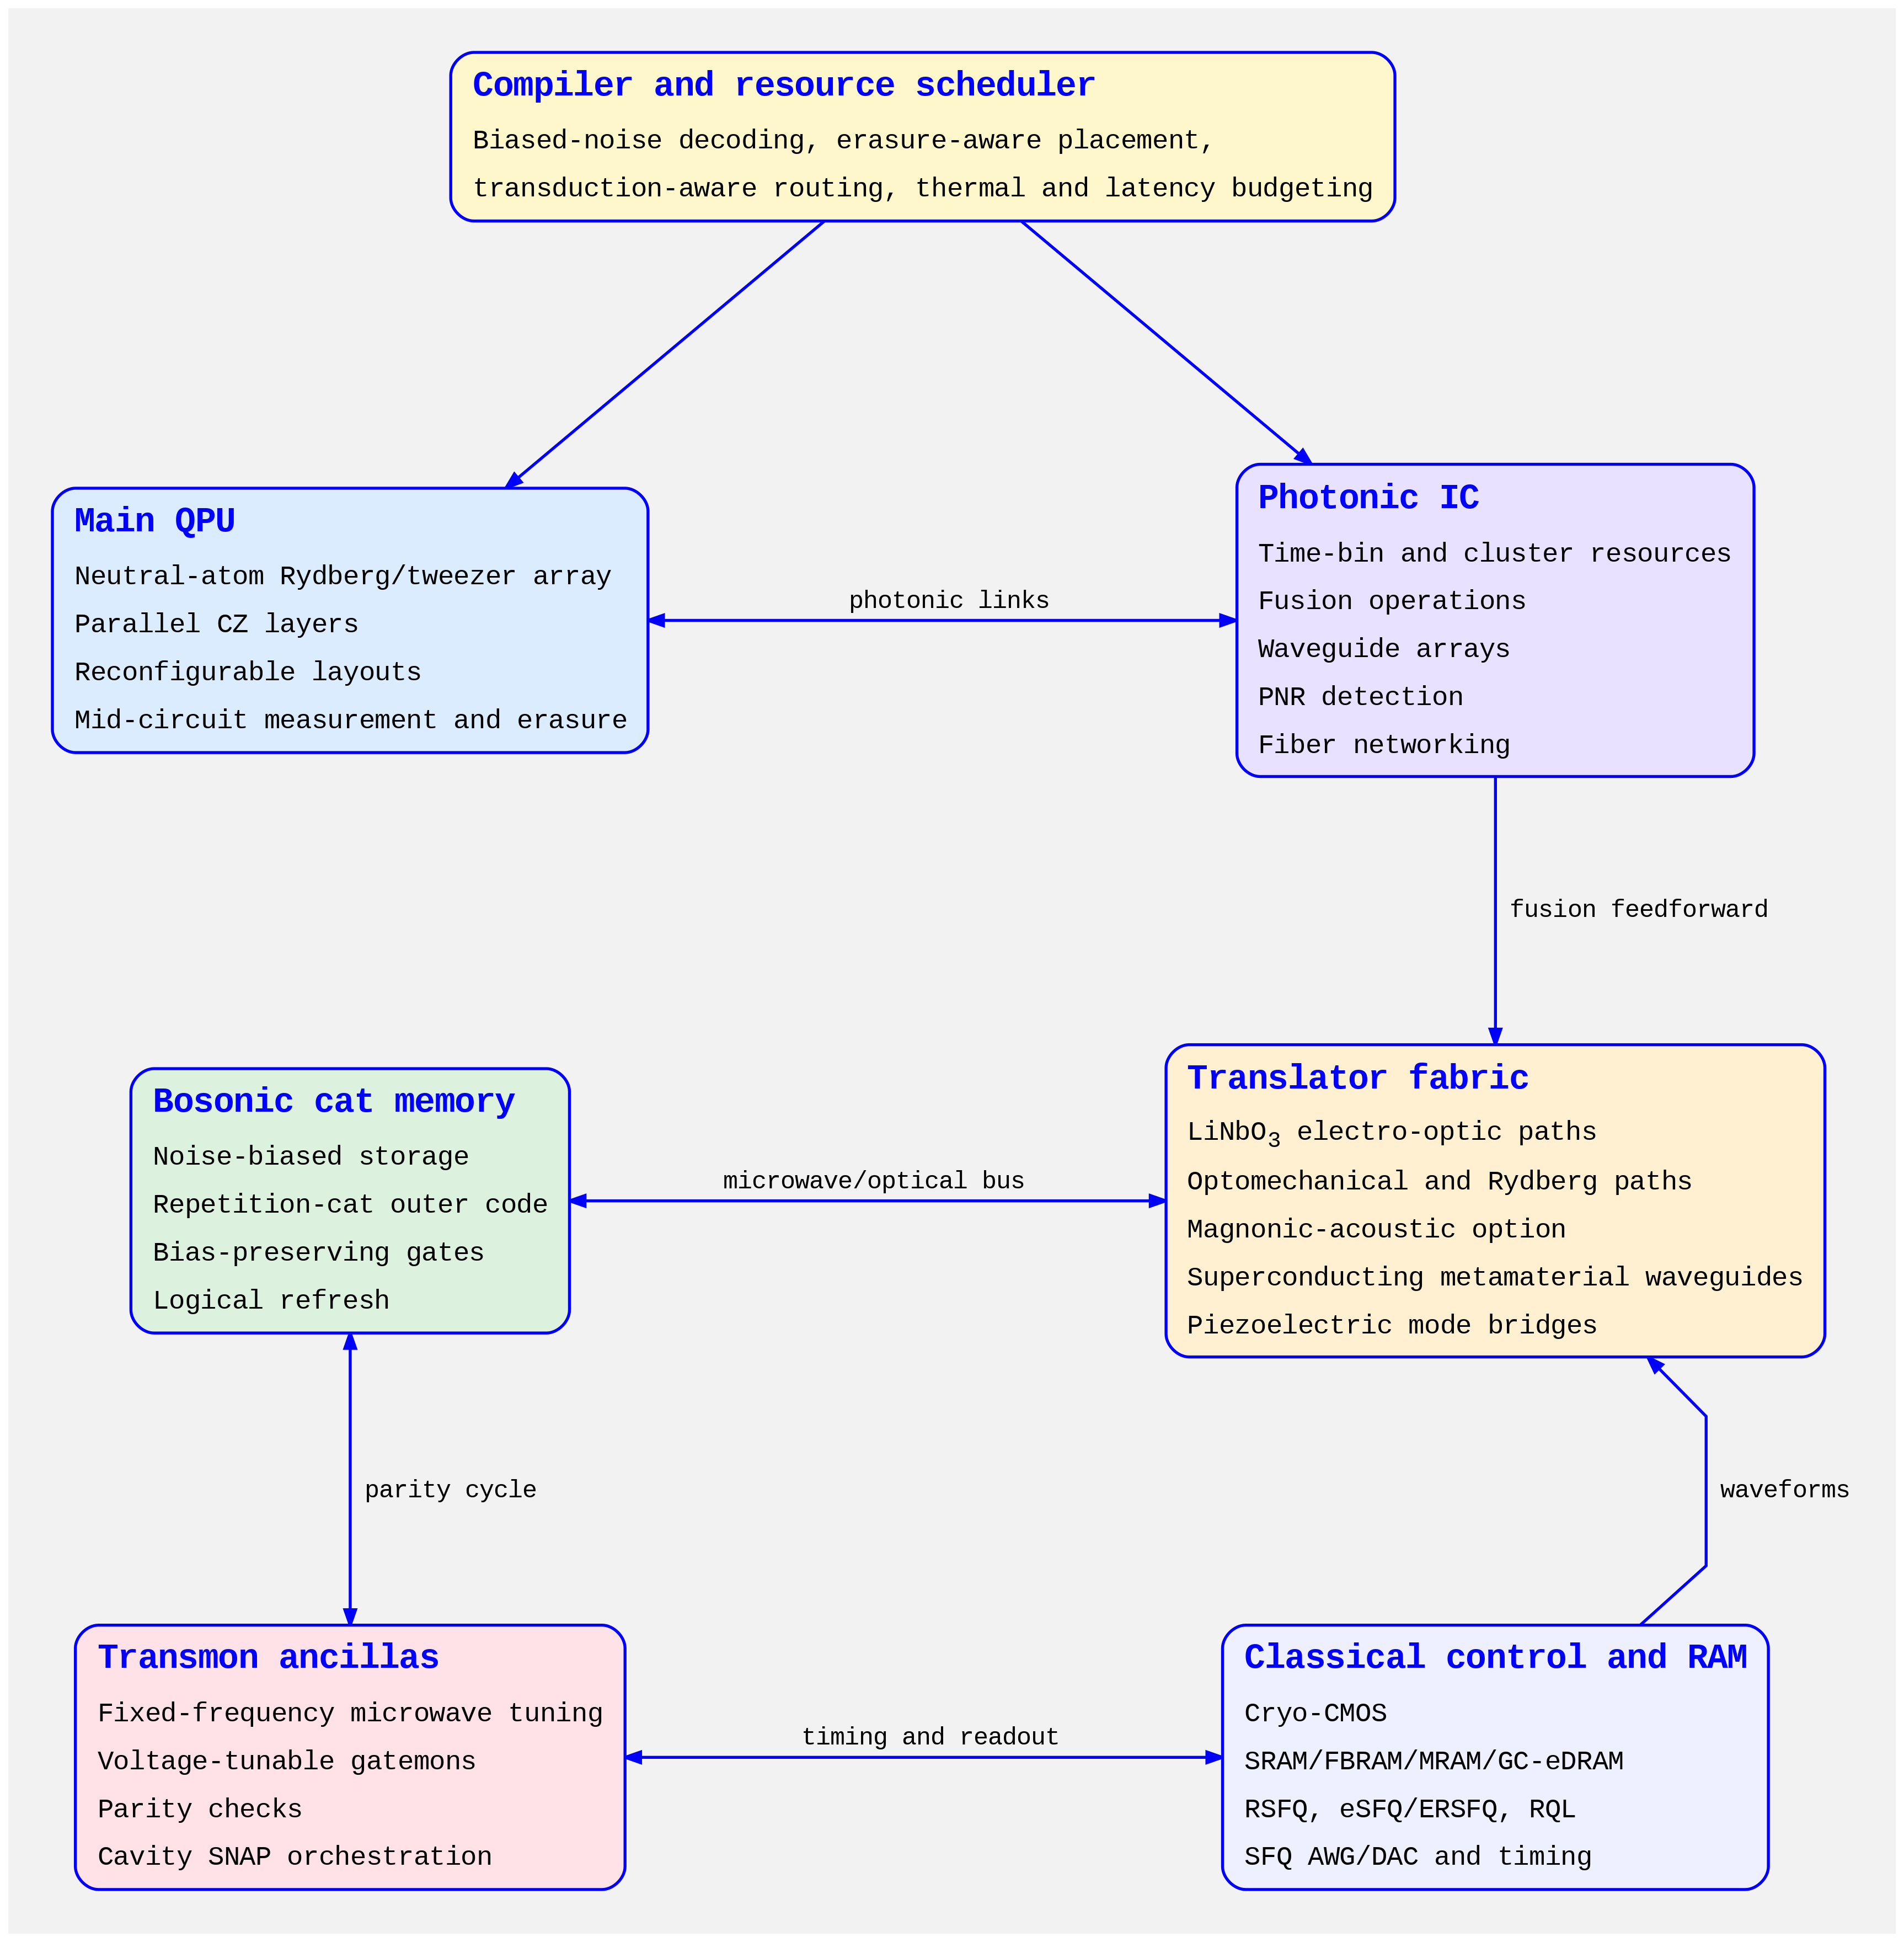

Rendered Graphviz PNG: heterogeneous_graphviz_architecture_map.png


In [14]:
"""Render a Graphviz-based heterogeneous quantum architecture map.
"""

from dataclasses import dataclass
from html import escape
from pathlib import Path
from textwrap import wrap
from typing import Iterable

import graphviz
from IPython.display import Image, display

try:
    from google.colab import files

    IN_COLAB = True
except ImportError:
    IN_COLAB = False


# =============================================================================
# CONTROL KNOBS
# =============================================================================

GRAPH_OUTPUT_STEM = "heterogeneous_graphviz_architecture_map"
GRAPH_OUTPUT_FORMAT = "png"
GRAPH_PREVIEW_WIDTH_PX = 1350
GRAPH_DPI = 250

GRAPH_FONT = "Tahoma"
BACKGROUND_COLOR = "#f2f2f2"
PURE_BLUE = "#0000ff"
BLACK = "#000000"

TITLE_FONT_SIZE = 18
BODY_FONT_SIZE = 14
EDGE_FONT_SIZE = 13

NODE_CELL_PADDING = 5
NODE_MARGIN = "0.08,0.05"
NODE_LINE_WIDTH = 1.55
NODE_MIN_WIDTH_IN = 3.10
NODE_MIN_HEIGHT_IN = 0.80

AUTO_LAYOUT_SPACING = True
SPACING_SCALE = 1.0
BASE_NODE_SEPARATION_IN = 1.00
BASE_RANK_SEPARATION_IN = 0.55
MAX_NODE_SEPARATION_IN = 2.15
MAX_RANK_SEPARATION_IN = 1.15

TITLE_WRAP_WIDTH = 70
BODY_WRAP_WIDTH = 70
EDGE_WRAP_WIDTH = 26

# One visible space is roughly 2 to 4 points depending on the installed font.
EDGE_LABEL_RIGHT_SHIFT_PT = 2.0
APPROX_SPACE_WIDTH_PT = 2.8

GRAPH_PAD_IN = 0.32
GRAPH_MARGIN_IN = 0.06

DOWNLOAD_RENDERED_PNG = False


# =============================================================================
# DATA MODELS
# =============================================================================

@dataclass(frozen=True)
class NodeSpec:
    """Describe one architecture node."""

    key: str
    title: str
    body_lines: tuple[str, ...]
    fillcolor: str
    rank: str


@dataclass(frozen=True)
class EdgeSpec:
    """Describe one architecture edge."""

    start: str
    end: str
    label: str | None = None
    direction: str = "forward"
    constraint: bool = True
    minlen: int = 1
    weight: int = 1
    style: str = "solid"


# =============================================================================
# ARCHITECTURE CONTENT
# =============================================================================

NODES: list[NodeSpec] = [
    NodeSpec(
        key="compiler",
        title="Compiler and resource scheduler",
        body_lines=(
            "Biased-noise decoding, erasure-aware placement,",
            "transduction-aware routing, thermal and latency budgeting",
        ),
        fillcolor="#fff7cc",
        rank="top",
    ),
    NodeSpec(
        key="main_qpu",
        title="Main QPU",
        body_lines=(
            "Neutral-atom Rydberg/tweezer array",
            "Parallel CZ layers",
            "Reconfigurable layouts",
            "Mid-circuit measurement and erasure",
        ),
        fillcolor="#dcecff",
        rank="row1",
    ),
    NodeSpec(
        key="photonic_ic",
        title="Photonic IC",
        body_lines=(
            "Time-bin and cluster resources",
            "Fusion operations",
            "Waveguide arrays",
            "PNR detection",
            "Fiber networking",
        ),
        fillcolor="#e8e1ff",
        rank="row1",
    ),
    NodeSpec(
        key="cat_memory",
        title="Bosonic cat memory",
        body_lines=(
            "Noise-biased storage",
            "Repetition-cat outer code",
            "Bias-preserving gates",
            "Logical refresh",
        ),
        fillcolor="#ddf1df",
        rank="row2",
    ),
    NodeSpec(
        key="translator",
        title="Translator fabric",
        body_lines=(
            "LiNbO3 electro-optic paths",
            "Optomechanical and Rydberg paths",
            "Magnonic-acoustic option",
            "Superconducting metamaterial waveguides",
            "Piezoelectric mode bridges",
        ),
        fillcolor="#fff0d2",
        rank="row2",
    ),
    NodeSpec(
        key="transmon",
        title="Transmon ancillas",
        body_lines=(
            "Fixed-frequency microwave tuning",
            "Voltage-tunable gatemons",
            "Parity checks",
            "Cavity SNAP orchestration",
        ),
        fillcolor="#ffe1e8",
        rank="row3",
    ),
    NodeSpec(
        key="control_ram",
        title="Classical control and RAM",
        body_lines=(
            "Cryo-CMOS",
            "SRAM/FBRAM/MRAM/GC-eDRAM",
            "RSFQ, eSFQ/ERSFQ, RQL",
            "SFQ AWG/DAC and timing",
        ),
        fillcolor="#eef0ff",
        rank="row3",
    ),
]

VISIBLE_EDGES: list[EdgeSpec] = [
    EdgeSpec(
        start="compiler",
        end="main_qpu",
        minlen=2,
        weight=6,
    ),
    EdgeSpec(
        start="compiler",
        end="photonic_ic",
        minlen=2,
        weight=6,
    ),
    EdgeSpec(
        start="main_qpu",
        end="photonic_ic",
        label="photonic links",
        direction="both",
        constraint=False,
        weight=3,
    ),
    EdgeSpec(
        start="photonic_ic",
        end="translator",
        label="fusion feedforward",
        minlen=2,
        weight=7,
    ),
    EdgeSpec(
        start="cat_memory",
        end="translator",
        label="microwave/optical bus",
        direction="both",
        constraint=False,
        weight=3,
    ),
    EdgeSpec(
        start="cat_memory",
        end="transmon",
        label="parity cycle",
        direction="both",
        minlen=2,
        weight=7,
    ),
    EdgeSpec(
        start="control_ram",
        end="translator",
        label="waveforms",
        constraint=False,
        weight=3,
    ),
    EdgeSpec(
        start="transmon",
        end="control_ram",
        label="timing and readout",
        direction="both",
        constraint=False,
        weight=3,
    ),
]

GUIDE_EDGES: list[EdgeSpec] = [
    EdgeSpec(
        start="main_qpu",
        end="cat_memory",
        constraint=True,
        minlen=2,
        weight=20,
        style="invis",
    ),
    EdgeSpec(
        start="translator",
        end="control_ram",
        constraint=True,
        minlen=2,
        weight=20,
        style="invis",
    ),
]


# =============================================================================
# LABEL AND SPACING HELPERS
# =============================================================================

def wrapped_text_lines(lines: Iterable[str], width: int) -> list[str]:
    """Wrap text lines while preserving whole words.

    Args:
        lines: Input text lines.
        width: Maximum line width in characters.

    Returns:
        Wrapped text lines.
    """
    result = []

    for line in lines:
        result.extend(
            wrap(
                line,
                width=width,
                break_long_words=False,
                break_on_hyphens=False,
            )
        )

    return result


def line_to_html(line: str) -> str:
    """Convert a text line to Graphviz HTML-like label content.

    Args:
        line: Plain text line.

    Returns:
        HTML-safe line content.
    """
    safe_line = escape(line)
    return safe_line.replace("LiNbO3", "LiNbO<SUB>3</SUB>")


def build_node_label(spec: NodeSpec) -> str:
    """Build a mixed-color HTML-like Graphviz node label.

    Args:
        spec: Node specification.

    Returns:
        Graphviz HTML-like label string.
    """
    title_lines = wrapped_text_lines((spec.title,), TITLE_WRAP_WIDTH)
    body_lines = wrapped_text_lines(spec.body_lines, BODY_WRAP_WIDTH)

    title_rows = "".join(
        '<TR><TD ALIGN="LEFT">'
        f'<FONT FACE="{GRAPH_FONT}" POINT-SIZE="{TITLE_FONT_SIZE}" '
        f'COLOR="{PURE_BLUE}"><B>{line_to_html(line)}</B></FONT>'
        "</TD></TR>"
        for line in title_lines
    )

    body_rows = "".join(
        '<TR><TD ALIGN="LEFT">'
        f'<FONT FACE="{GRAPH_FONT}" POINT-SIZE="{BODY_FONT_SIZE}" '
        f'COLOR="{BLACK}">{line_to_html(line)}</FONT>'
        "</TD></TR>"
        for line in body_lines
    )

    return (
        "<\n"
        f'<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" '
        f'CELLPADDING="{NODE_CELL_PADDING}">'
        f"{title_rows}{body_rows}"
        "</TABLE>\n"
        ">"
    )


def edge_label_shift_spaces() -> int:
    """Estimate the number of plain spaces for a small rightward label shift.

    Returns:
        Number of leading spaces applied to each edge-label line.
    """
    shift_spaces = round(EDGE_LABEL_RIGHT_SHIFT_PT / APPROX_SPACE_WIDTH_PT)
    return max(1, shift_spaces)


def build_edge_label(text: str | None) -> str | None:
    """Build a wrapped edge label with a slight rightward visual shift.

    Args:
        text: Edge-label text.

    Returns:
        Wrapped and shifted label text, or None.
    """
    if text is None:
        return None

    prefix = " " * edge_label_shift_spaces()
    wrapped_lines = wrapped_text_lines((text,), EDGE_WRAP_WIDTH)

    return "\n".join(f"{prefix}{line}" for line in wrapped_lines)


def estimate_spacing(nodes: Iterable[NodeSpec]) -> tuple[float, float]:
    """Estimate Graphviz node and rank spacing from text density.

    Args:
        nodes: Architecture nodes.

    Returns:
        Node separation and rank separation in inches.
    """
    specs = list(nodes)

    max_line_count = max(
        len(wrapped_text_lines((spec.title,), TITLE_WRAP_WIDTH))
        + len(wrapped_text_lines(spec.body_lines, BODY_WRAP_WIDTH))
        for spec in specs
    )

    max_line_length = max(
        max(len(line) for line in [spec.title, *spec.body_lines])
        for spec in specs
    )

    node_separation = BASE_NODE_SEPARATION_IN + 0.018 * max_line_length
    rank_separation = BASE_RANK_SEPARATION_IN + 0.050 * max_line_count

    if AUTO_LAYOUT_SPACING:
        return (
            min(MAX_NODE_SEPARATION_IN, node_separation * SPACING_SCALE),
            min(MAX_RANK_SEPARATION_IN, rank_separation * SPACING_SCALE),
        )

    return BASE_NODE_SEPARATION_IN, BASE_RANK_SEPARATION_IN


# =============================================================================
# GRAPH CONSTRUCTION
# =============================================================================

def add_rank_groups(
    graph: graphviz.Digraph,
    nodes: Iterable[NodeSpec],
) -> None:
    """Add Graphviz rank groups.

    Args:
        graph: Graphviz directed graph.
        nodes: Architecture nodes.
    """
    for rank_name in ("top", "row1", "row2", "row3"):
        with graph.subgraph(name=f"rank_{rank_name}") as row:
            row.attr(rank="same")

            for spec in nodes:
                if spec.rank == rank_name:
                    row.node(spec.key)


def add_edge(graph: graphviz.Digraph, spec: EdgeSpec) -> None:
    """Add a styled edge to the graph.

    Args:
        graph: Graphviz directed graph.
        spec: Edge specification.
    """
    attrs = {
        "constraint": "true" if spec.constraint else "false",
        "minlen": str(spec.minlen),
        "style": spec.style,
        "weight": str(spec.weight),
    }

    if spec.direction == "both":
        attrs["arrowhead"] = "normal"
        attrs["arrowtail"] = "normal"
        attrs["dir"] = "both"

    edge_label = build_edge_label(spec.label)

    if edge_label is None:
        graph.edge(spec.start, spec.end, **attrs)
        return

    graph.edge(spec.start, spec.end, label=edge_label, **attrs)


def build_architecture_graph() -> graphviz.Digraph:
    """Build the architecture Graphviz object.

    Returns:
        A Graphviz directed graph.
    """
    node_separation, rank_separation = estimate_spacing(NODES)

    graph = graphviz.Digraph("architecture_map", engine="dot")

    graph.attr(
        bgcolor=BACKGROUND_COLOR,
        concentrate="false",
        dpi=str(GRAPH_DPI),
        margin=f"{GRAPH_MARGIN_IN:.2f}",
        newrank="true",
        nodesep=f"{node_separation:.2f}",
        outputorder="edgesfirst",
        pad=f"{GRAPH_PAD_IN:.2f}",
        rankdir="TB",
        ranksep=f"{rank_separation:.2f}",
        splines="polyline",
    )

    graph.attr(
        "node",
        color=PURE_BLUE,
        fixedsize="false",
        fontname=GRAPH_FONT,
        height=f"{NODE_MIN_HEIGHT_IN:.2f}",
        margin=NODE_MARGIN,
        penwidth=f"{NODE_LINE_WIDTH:.2f}",
        shape="box",
        style="filled,rounded",
        width=f"{NODE_MIN_WIDTH_IN:.2f}",
    )

    graph.attr(
        "edge",
        arrowsize="0.80",
        color=PURE_BLUE,
        decorate="false",
        fontcolor=BLACK,
        fontname=GRAPH_FONT,
        fontsize=str(EDGE_FONT_SIZE),
        labelfloat="false",
        labeldistance="1.25",
        penwidth="1.55",
    )

    for spec in NODES:
        graph.node(
            spec.key,
            label=build_node_label(spec),
            fillcolor=spec.fillcolor,
        )

    add_rank_groups(graph, NODES)

    for spec in VISIBLE_EDGES:
        add_edge(graph, spec)

    for spec in GUIDE_EDGES:
        add_edge(graph, spec)

    return graph


def render_and_display_graph(graph: graphviz.Digraph) -> Path:
    """Render the graph to PNG and display the rendered file.

    Args:
        graph: Graphviz graph object.

    Returns:
        Path to the rendered PNG.
    """
    rendered_path = Path(
        graph.render(
            GRAPH_OUTPUT_STEM,
            format=GRAPH_OUTPUT_FORMAT,
            cleanup=True,
        )
    )

    display(Image(filename=str(rendered_path), width=GRAPH_PREVIEW_WIDTH_PX))

    if IN_COLAB and DOWNLOAD_RENDERED_PNG:
        files.download(str(rendered_path))

    return rendered_path


# =============================================================================
# EXECUTION
# =============================================================================

architecture_graph = build_architecture_graph()
rendered_graph_path = render_and_display_graph(architecture_graph)

print(f"Rendered Graphviz PNG: {rendered_graph_path}")